In [10]:
from functions import *
import numpy as np

"""
The difference between the best center and the second best center is large (on average eta_1-eta_2 ~ 1/(N_c+1), so the system is naturally almost
monocentric for small populations, and a Clark profile emerges

Z_ij = eta_j - (d_ij/l) * [1 + (T(j)/c)^mu]
"""

seed = 23531690

R = 6.0                              # city radius, km
inv_nc=4                             # a center every inv_nc km^2
N_c = int(np.pi * R**2 / inv_nc)     # number of centers in the city, given the density of centers

c = 5_000.0                          # network capacity
mu = 4.0                             # exponent of the congestion term

s = 24_000.0                         # EUR/year
cost_per_km_trip = 1.5               # EUR/km
trips_per_year = 2 * 220
t_cost = cost_per_km_trip * trips_per_year
l = s / t_cost                


P_max = 2_000_000
n_bins = 80
r0_ker = np.sqrt(inv_nc)              # kernel density corresponds to the typical distance between centers

np.random.seed(seed)

P_star = P_star_theory(l, R, N_c, c, mu)
print(f"N_c={N_c}  l/R={l/R:.2f}  P*={P_star:.0f}  P_max={P_max:,}")

sampling='uniform'  # 'uniform' or 'clark'

cx, cy, eta, wx, wy, assignment = run_growth(P_max=P_max, N_c=N_c, R=R, l=l, c=c, mu=mu, sampling=sampling, seed=seed, k0_ker=r0_ker)

T_final = np.bincount(assignment, minlength=N_c).astype(float)  # how many workers to each center
print(f"k_final = {int((T_final>0).sum())}/{N_c}   top values: {np.sort(T_final)[::-1][:5].astype(np.uint32)}")

sampling='clark'  # 'uniform' or 'clark'
cx_clark, cy_clark, eta_clark, wx_clark, wy_clark, assignment_clark = run_growth(P_max=P_max, N_c=N_c, R=R, l=l, c=c, mu=mu, sampling=sampling, seed=seed, k0_ker=r0_ker)
T_final_clark = np.bincount(assignment_clark, minlength=N_c).astype(float)  # how many workers to each center
print(f"k_final = {int((T_final_clark>0).sum())}/{N_c}   top values: {np.sort(T_final_clark)[::-1][:5].astype(np.uint32)}")


N_c=28  l/R=6.06  P*=3410  P_max=2,000,000
k_final = 28/28   top values: [91795 88631 87920 80345 75759]
k_final = 28/28   top values: [81235 79381 77981 76641 76506]


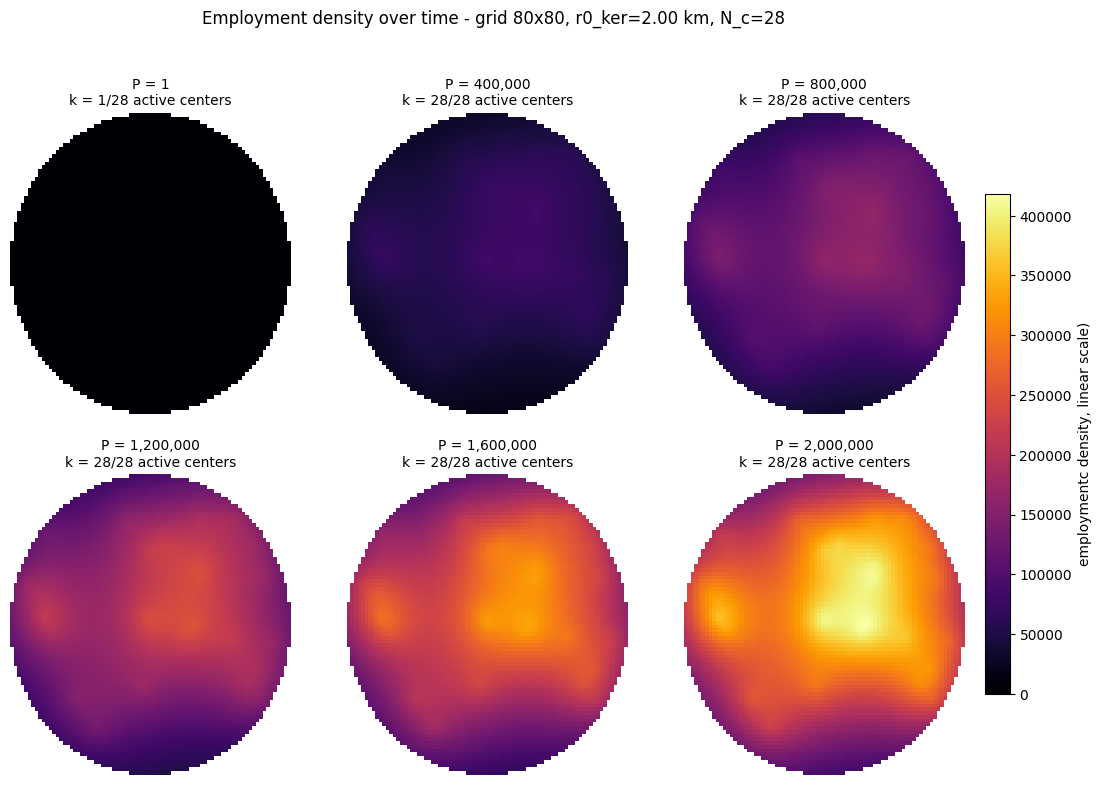

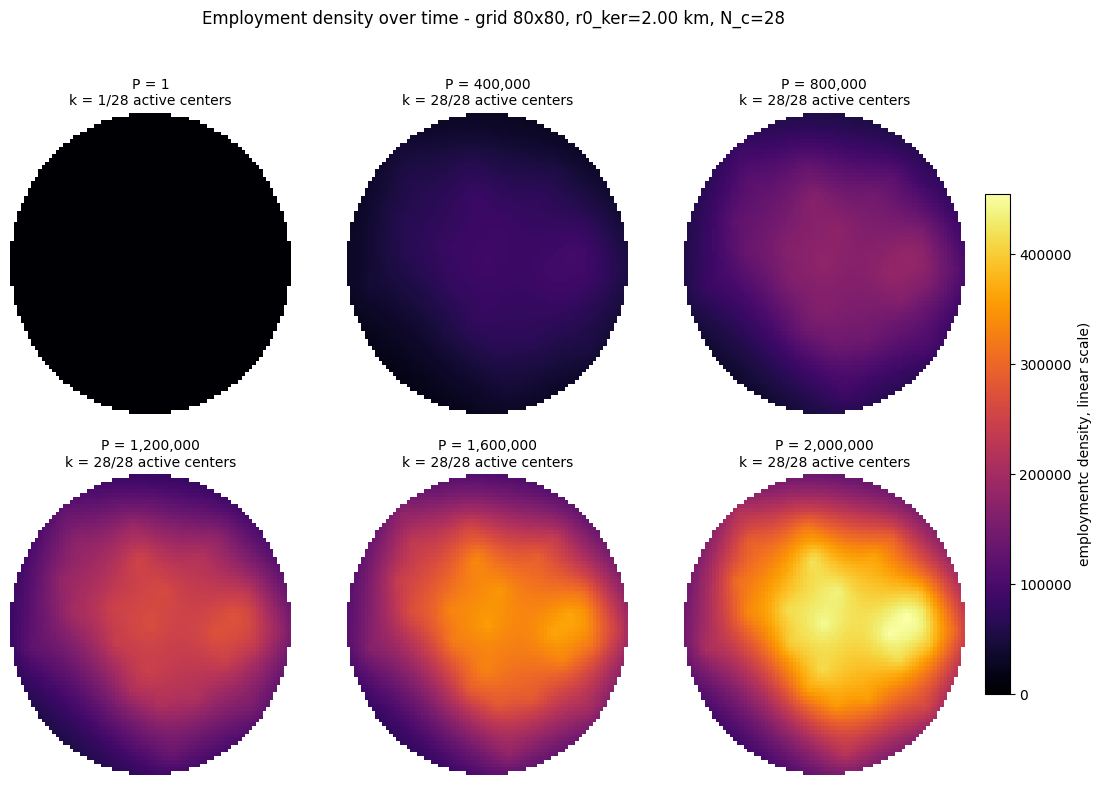

In [11]:
n_snapshots = 6
color_scale = "linear"      # "linear" or "log"
cmap_name = "inferno"

plot_density_evolution(cx, cy, assignment, N_c, R, n_bins, r0_ker,
                        n_snapshots=n_snapshots, color_scale=color_scale,
                        cmap_name=cmap_name, P_max=P_max)

plot_density_evolution(cx_clark, cy_clark, assignment_clark, N_c, R, n_bins, r0_ker,
                        n_snapshots=n_snapshots, color_scale=color_scale,
                        cmap_name=cmap_name, P_max=P_max)

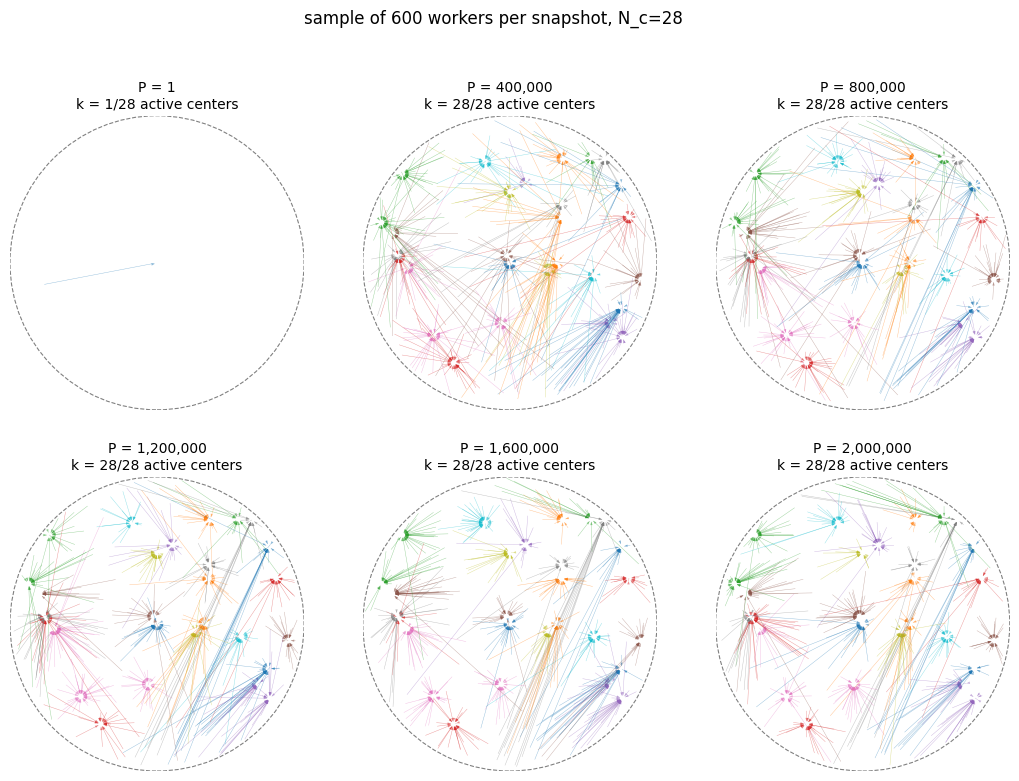

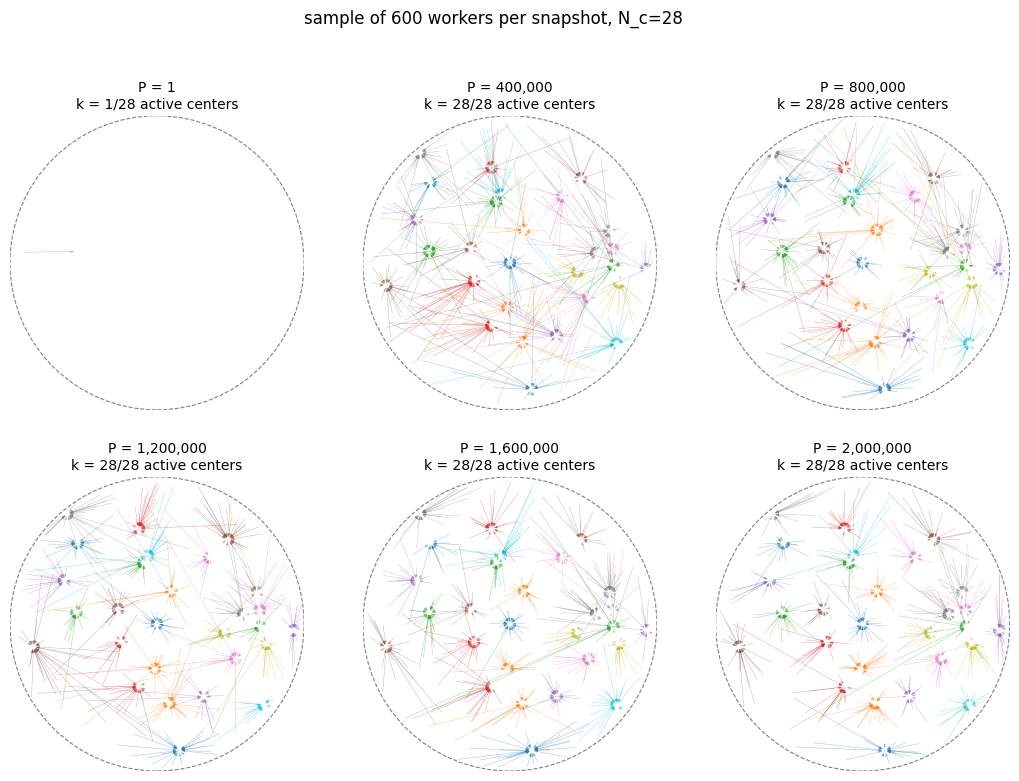

In [12]:
n_snapshots_arrows = 6         # number of snapshots to plot
n_workers_per_snapshot = 600   # subsample: one worker sampled each n_workers_per_snapshot
arrow_alpha = 0.5
arrow_width = 0.3
arrows_cmap_name = "tab10"     # categorical colormap


HEAD_LEN_PTS = 2.4           # length of the head along the arrow direction
HEAD_HALF_WIDTH_PTS = 0.85   # half-width of the head, perpendicular to the arrow
SHRINK_PTS = 2.0             # gap left at both ends (matches annotate's default shrinkA/shrinkB=2)

plot_arrows_evolution(cx, cy, wx, wy, assignment, N_c, R, n_snapshots=n_snapshots_arrows,
                       n_workers_per_snapshot=n_workers_per_snapshot,
                       cmap_name=arrows_cmap_name, P_init=1, P_max=P_max,
                       head_len_pts=HEAD_LEN_PTS,
                       head_half_width_pts=HEAD_HALF_WIDTH_PTS, shrink_pts=SHRINK_PTS,
                       arrow_alpha=arrow_alpha, arrow_width=arrow_width)

plot_arrows_evolution(cx_clark, cy_clark, wx_clark, wy_clark, assignment_clark, N_c, R, n_snapshots=n_snapshots_arrows,
                       n_workers_per_snapshot=n_workers_per_snapshot,
                       cmap_name=arrows_cmap_name, P_init=1, P_max=P_max,
                       head_len_pts=HEAD_LEN_PTS,
                       head_half_width_pts=HEAD_HALF_WIDTH_PTS, shrink_pts=SHRINK_PTS,
                       arrow_alpha=arrow_alpha, arrow_width=arrow_width)